<font color = green >

## Home Task

</font>

Apply various clustering algorithms 

- Agglomerative clustering using `complete` linkage 
- Agglomerative clustering using `single` linkage 
- DBSCAN
- Use elbow method to determine the best k for Kmeans



<font color = green >

### Load libraries

</font>

In [178]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np 

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

<font color = green >

###  Data 

</font>


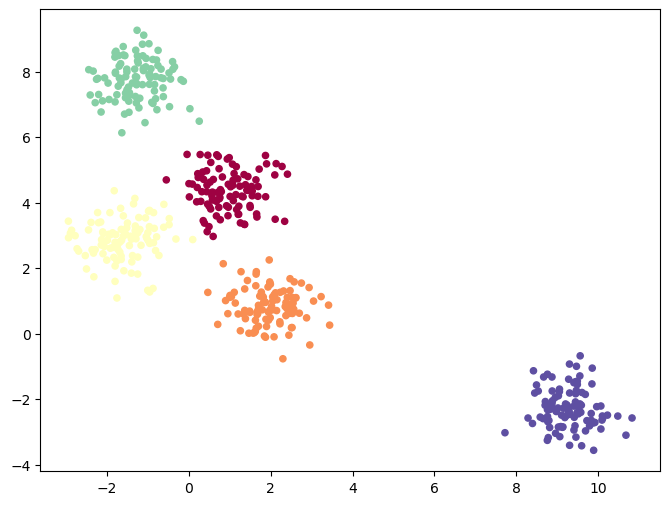

In [179]:
 
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)  

<font color = green >

### Agglomerative clustering using `complete` linkage 

</font>


In [180]:
n_clusters = 5
clf = AgglomerativeClustering(n_clusters= n_clusters, linkage= 'complete') 
predicted = clf.fit_predict(X)


Text(0.5, 1.0, 'sklearn kmeans')

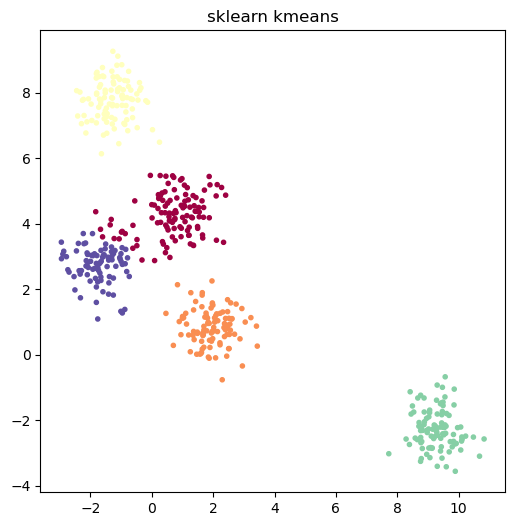

In [181]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], marker= '.') 
plt.title ('sklearn kmeans')

<font color = green >

### Agglomerative clustering using `single` linkage 

</font>


In [182]:
clf = AgglomerativeClustering(n_clusters= n_clusters, linkage= 'single') 
predicted = clf.fit_predict(X)


Text(0.5, 1.0, 'sklearn agglomerative single linkage')

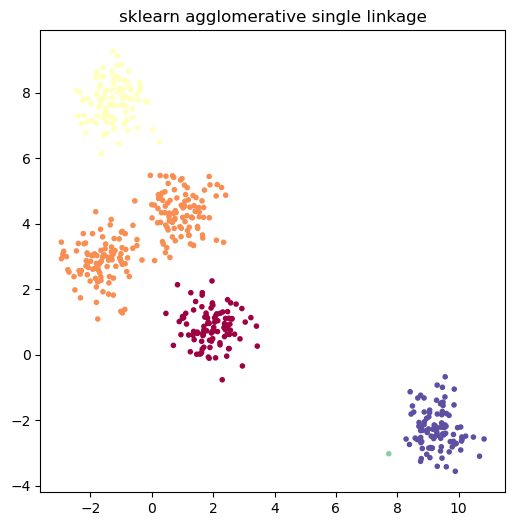

In [183]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=colors[predicted], marker= '.') 
plt.title ('sklearn agglomerative single linkage')

<font color = green >

### DBSCAN

</font>

Estimated number of clusters: 5
Estimated number of noise points: 16


Text(0.5, 1.0, 'Estimated number of clusters: 5')

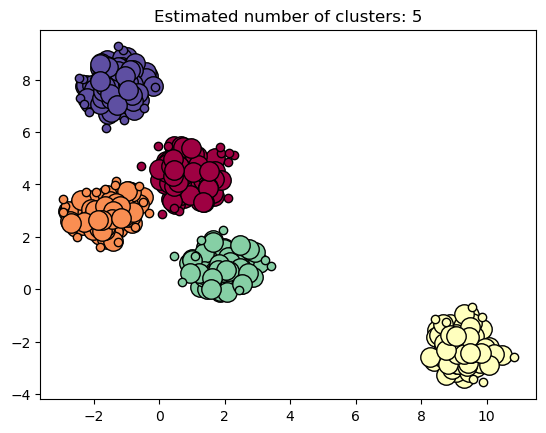

In [184]:
plt.figure()
  
db = DBSCAN(eps=0.6, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
 
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

 
unique_labels = set(labels)
 
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Estimated number of clusters: %d' % n_clusters_)

<font color = green >

### Use elbow method to determine the best k for Kmeans

</font>

In [185]:
dis_sqr  = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    dis_sqr .append(kmeans.inertia_)
    
dis_sqr     

f:\Anaconda3_Py_Env2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
f:\Anaconda3_Py_Env2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
f:\Anaconda3_Py_Env2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
f:\Anaconda3_Py_Env2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

[13801.118960595788,
 3798.0664186953177,
 1645.9218979916382,
 787.0676994559474,
 343.8869179432984,
 318.00598586232627,
 292.8404515761288,
 269.0030998351118,
 244.8953449350449,
 232.99536158411135]

Text(0.5, 1.0, 'Elbow method')

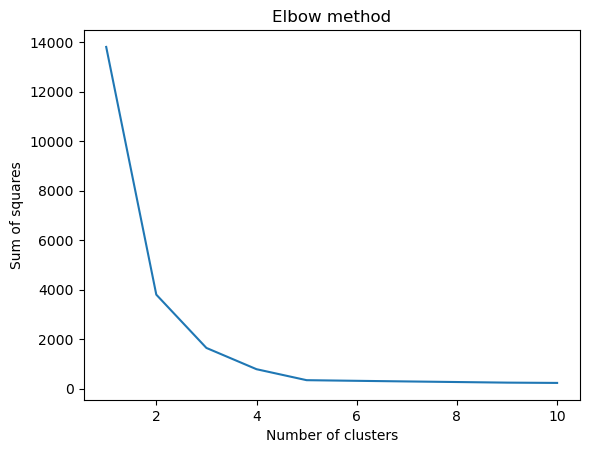

In [186]:

plt.plot(K_range, dis_sqr )
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squares')
plt.title('Elbow method')
 